In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append("..")
from config import *
from metric import *

## RQ2-1 Does the Router Prediction generalize as it is?

In [2]:
def parse_file_name(file_name):
    split_name = file_name.split('_')
    if file_name.startswith('internal_state'):
        layer = int(split_name[2][-2:])
        strong_model = split_name[3]
        weak_model = split_name[4]
        return {
            "router_strong": strong_model,
            "router_weak": weak_model,
            "input": "internal state",
            "type": {16: "1/2", 20: "1/2", 21: "2/3", 27: "2/3", 24: "3/4", 30: "3/4"}[layer],
        }
    else:
        embedding_model = split_name[0]
        strong_model = split_name[1]
        weak_model = split_name[2]
        return {
            "router_strong": strong_model,
            "router_weak": weak_model,
            "input": "prompt embedding",
            "type": embedding_model,
        }

def iterate_over_every_pair(result, probs_df, benchmark):
    result_list = list()
    for strong_model_name in STRONG_MODELS:
        for weak_model_name in WEAK_MODELS:
            new_result = result.copy()
            new_result['strong'] = strong_model_name
            new_result['weak'] = weak_model_name
            ro_dict = compute_router_optimality(
                benchmark=benchmark, 
                strong_model_name=strong_model_name, 
                weak_model_name=weak_model_name, 
                strong_model_result_path=path_to_result_file_for(benchmark, strong_model_name),
                weak_model_result_path=path_to_result_file_for(benchmark, weak_model_name),
                probs_df=probs_df)
            new_result.update(ro_dict)
            result_list.append(new_result)
    return result_list

def compute_ro_for(prompt_type, is_code_gen=False):
    benchmarks = CODE_GENERATION_BENCHMARKS if is_code_gen else TESTING_BENCHMARKS
    ro_results = list()
    for benchmark in benchmarks:
        print(f'Now processing {benchmark}')
        bench_dir = f"../results/{benchmark.lower()}/preset/"
        for strong_model_name in STRONG_MODELS:
            for weak_model_name in WEAK_MODELS:
                for file in sorted(os.listdir(bench_dir)):
                    if not file.endswith(f'{prompt_type}.pkl') or strong_model_name not in file or weak_model_name not in file:
                        continue
                    result = parse_file_name(file)
                    result['benchmark'] = benchmark
                    probs_df = pd.read_pickle(f"{bench_dir}/{file}")
                    ro_results.extend(iterate_over_every_pair(result, probs_df, benchmark))
    return ro_results

In [3]:
ro_results = compute_ro_for(prompt_type=DEFAULT_PROMPT_TYPE)
df = pd.DataFrame(ro_results)
print(len(ro_results))

Now processing TestEval_line
Now processing TestEval_branch
Now processing TestEval_path
Now processing TestEval_total
Now processing LIBRO_d4j
3000


Following RQ1, we only adopt the best performing option for each input
- **Internal state** extracted from the **3/4-th layer**
- **Prompt Embedding** embedded by **text-embedding-3-large**

In [4]:
df = df[(df['type'] == DEFAULT_INTERNAL_STATE_TYPE) | (df['type'] == DEFAULT_EMBEDDING_TYPE)]

In [5]:
df

,router_strong,router_weak,input,type,benchmark,strong,weak,Logistic Regression,SVM,MLP,Ensemble,RouteLLM
20,gpt-4o,llama3-8b,internal state,3/4,TestEval_line,gpt-4o,llama3-8b,0.611632,0.595376,0.591597,0.614449,0.653214
21,gpt-4o,llama3-8b,internal state,3/4,TestEval_line,gpt-4o,llama3.1-8b,0.533465,0.497178,0.582127,0.559503,0.538305
22,gpt-4o,llama3-8b,internal state,3/4,TestEval_line,gpt-4o,mistral-nemo-12b,0.499490,0.498490,0.556253,0.530469,0.533337
23,gpt-4o,llama3-8b,internal state,3/4,TestEval_line,gpt-4o,qwen2.5-coder-7b,0.549793,0.585692,0.592129,0.593029,0.603147
24,gpt-4o,llama3-8b,internal state,3/4,TestEval_line,gpt-4o,phi4-14b,0.488573,0.500882,0.534414,0.525585,0.531422
...,...,...,...,...,...,...,...,...,...,...,...,...
2985,gemini-2.5-flash-lite,phi4-14b,prompt embedding,text-embedding-3-large,LIBRO_d4j,gemini-2.5-flash-lite,llama3-8b,0.476421,0.478738,0.504120,0.501448,0.574087
2986,gemini-2.5-flash-lite,phi4-14b,prompt embedding,text-embedding-3-large,LIBRO_d4j,gemini-2.5-flash-lite,llama3.1-8b,0.457412,0.469933,0.493327,0.485012,0.569292
2987,gemini-2.5-flash-lite,phi4-14b,prompt embedding,text-embedding-3-large,LIBRO_d4j,gemini-2.5-flash-lite,mistral-nemo-12b,0.465151,0.473397,0.491326,0.480243,0.554431
2988,gemini-2.5-flash-lite,phi4-14b,prompt embedding,text-embedding-3-large,LIBRO_d4j,gemini-2.5-flash-lite,qwen2.5-coder-7b,0.473287,0.509481,0.469906,0.485135,0.532510


### Scenario 0. router_strong == strong & router_weak == weak

In [6]:
df[(df['router_strong'] == df['strong']) & (df['router_weak'] == df['weak'])].groupby(['input'])['Logistic Regression'].agg('mean')

input
internal state      0.542582
prompt embedding    0.519937
Name: Logistic Regression, dtype: float64

#### Scenario 1. router_strong == strong & router_weak != weak

In [7]:
df[(df['router_strong'] == df['strong']) & (df['router_weak'] != df['weak'])].groupby(['input'])['Logistic Regression'].agg('mean')

input
internal state      0.522945
prompt embedding    0.510231
Name: Logistic Regression, dtype: float64

#### Scenario 2. router_strong != strong & router_weak == weak

In [8]:
df[(df['router_strong'] != df['strong']) & (df['router_weak'] == df['weak'])].groupby(['input'])['Logistic Regression'].agg('mean')

input
internal state      0.521987
prompt embedding    0.514505
Name: Logistic Regression, dtype: float64

### Scenario 3. router_strong != strong & router_weak != weak

In [9]:
df[(df['router_strong'] != df['strong']) & (df['router_weak'] != df['weak'])].groupby(['input'])['Logistic Regression'].agg('mean')

input
internal state      0.503997
prompt embedding    0.507269
Name: Logistic Regression, dtype: float64

### Summary

In [10]:
def construct_model_generalization_table(df):
    summaries = dict()
    for algorithm in ALGORITHMS:
        summaries[algorithm] = pd.concat([
            df[(df['router_strong'] == df['strong']) & (df['router_weak'] == df['weak'])].groupby(['input'])[algorithm].agg(['mean', 'std']),
            df[(df['router_strong'] == df['strong']) & (df['router_weak'] != df['weak'])].groupby(['input'])[algorithm].agg(['mean', 'std']),
            df[(df['router_strong'] != df['strong']) & (df['router_weak'] == df['weak'])].groupby(['input'])[algorithm].agg(['mean', 'std']),
            df[(df['router_strong'] != df['strong']) & (df['router_weak'] != df['weak'])].groupby(['input'])[algorithm].agg(['mean', 'std']), 
        ], axis=1)

    rows = []
    algo_names = []

    for algo, df_stat in summaries.items():
        algo_names.append(algo)
        current_row = []
        
        row_int = df_stat.loc['internal state']
        row_emb = df_stat.loc['prompt embedding']
        
        for i in range(4):
            idx_mean = i * 2
            idx_std = i * 2 + 1
            
            val_int = f"{row_int.iloc[idx_mean]:.3f} ({row_int.iloc[idx_std]:.3f})"
            current_row.append(val_int)
            
            val_emb = f"{row_emb.iloc[idx_mean]:.3f} ({row_emb.iloc[idx_std]:.3f})"
            current_row.append(val_emb)
            
        rows.append(current_row)

    top_level = ['S0', 'S0', 'S1', 'S1', 'S2', 'S2', 'S3', 'S3']
    sub_level = ['Internal State', 'Prompt Embedding'] * 4
    columns = pd.MultiIndex.from_arrays([top_level, sub_level], names=['Group', 'Input'])

    final_df = pd.DataFrame(rows, index=algo_names, columns=columns)
    final_df.index.name = 'Algorithm'

    print(final_df.to_latex())

In [11]:
# Testing
construct_model_generalization_table(df)

\begin{tabular}{lllllllll}
\toprule
Group & \multicolumn{2}{r}{S0} & \multicolumn{2}{r}{S1} & \multicolumn{2}{r}{S2} & \multicolumn{2}{r}{S3} \\
Input & Internal State & Prompt Embedding & Internal State & Prompt Embedding & Internal State & Prompt Embedding & Internal State & Prompt Embedding \\
Algorithm &  &  &  &  &  &  &  &  \\
\midrule
Logistic Regression & 0.543 (0.053) & 0.520 (0.051) & 0.523 (0.051) & 0.510 (0.041) & 0.522 (0.046) & 0.515 (0.049) & 0.504 (0.038) & 0.507 (0.037) \\
SVM & 0.515 (0.050) & 0.499 (0.045) & 0.510 (0.042) & 0.498 (0.038) & 0.511 (0.045) & 0.506 (0.038) & 0.507 (0.036) & 0.506 (0.036) \\
MLP & 0.542 (0.046) & 0.523 (0.045) & 0.528 (0.051) & 0.513 (0.037) & 0.519 (0.042) & 0.518 (0.044) & 0.506 (0.035) & 0.508 (0.038) \\
Ensemble & 0.543 (0.053) & 0.521 (0.050) & 0.526 (0.050) & 0.511 (0.041) & 0.521 (0.051) & 0.515 (0.050) & 0.507 (0.039) & 0.507 (0.040) \\
RouteLLM & 0.545 (0.053) & 0.520 (0.039) & 0.527 (0.046) & 0.512 (0.037) & 0.521 (0.048) & 0.51

In [12]:
# Code Generation
ro_results = compute_ro_for(prompt_type=DEFAULT_PROMPT_TYPE, is_code_gen=True)
df = pd.DataFrame(ro_results)
df = df[(df['type'] == DEFAULT_INTERNAL_STATE_TYPE) | (df['type'] == DEFAULT_EMBEDDING_TYPE)]
construct_model_generalization_table(df)

Now processing HumanEval
Now processing APPS
\begin{tabular}{lllllllll}
\toprule
Group & \multicolumn{2}{r}{S0} & \multicolumn{2}{r}{S1} & \multicolumn{2}{r}{S2} & \multicolumn{2}{r}{S3} \\
Input & Internal State & Prompt Embedding & Internal State & Prompt Embedding & Internal State & Prompt Embedding & Internal State & Prompt Embedding \\
Algorithm &  &  &  &  &  &  &  &  \\
\midrule
Logistic Regression & 0.674 (0.134) & 0.608 (0.107) & 0.646 (0.155) & 0.589 (0.127) & 0.613 (0.090) & 0.592 (0.095) & 0.583 (0.105) & 0.572 (0.108) \\
SVM & 0.657 (0.150) & 0.609 (0.101) & 0.634 (0.151) & 0.588 (0.119) & 0.597 (0.120) & 0.615 (0.089) & 0.574 (0.116) & 0.593 (0.110) \\
MLP & 0.652 (0.093) & 0.623 (0.073) & 0.614 (0.105) & 0.593 (0.088) & 0.606 (0.081) & 0.594 (0.063) & 0.566 (0.090) & 0.563 (0.077) \\
Ensemble & 0.683 (0.127) & 0.631 (0.100) & 0.648 (0.149) & 0.603 (0.120) & 0.617 (0.090) & 0.607 (0.082) & 0.579 (0.105) & 0.578 (0.101) \\
RouteLLM & 0.654 (0.100) & 0.625 (0.069) & 0.620 (

## RQ2-2 Does the Router trained on one benchmark generalize to others?

In [13]:
def parse_file_name(file_name):
    split_name = file_name.split('_')
    strong_model = split_name[-4]
    weak_model = split_name[-3]
    if file_name.startswith('internal_state'):
        layer = int(split_name[2][-2:])
        source_benchmark = '_'.join(split_name[4:-4])
        return {
            "source": source_benchmark,
            "strong": strong_model, 
            "weak": weak_model,
            "input": "internal state",
            "type": {16: "1/2", 20: "1/2", 21: "2/3", 27: "2/3", 24: "3/4", 30: "3/4"}[layer],
        }    
    else:
        embedding_model = split_name[0]
        source_benchmark = '_'.join(split_name[2:-4])
        return {
            "source": source_benchmark,
            "strong": strong_model,
            "weak": weak_model,
            "input": "prompt embedding",
            "type": embedding_model,
        }
    
def compute_ro_for(prompt_type):
    ro_results = list()
    for benchmark in TESTING_BENCHMARKS + CODE_GENERATION_BENCHMARKS:
        print(f'Now processing {benchmark}')
        bench_dir = f"../results/{benchmark.lower()}/benchmark_generalization/"
        for strong_model_name in STRONG_MODELS:
            for weak_model_name in WEAK_MODELS:
                for file in sorted(os.listdir(bench_dir)):
                    if not file.endswith(f'{prompt_type}.pkl') or strong_model_name not in file or weak_model_name not in file:
                        continue
                    result = parse_file_name(file)
                    result['benchmark'] = benchmark
                    df = pd.read_pickle(f"{bench_dir}/{file}")
                    ro_dict = compute_router_optimality(
                        benchmark=benchmark, 
                        strong_model_name=strong_model_name, 
                        weak_model_name=weak_model_name, 
                        strong_model_result_path=path_to_result_file_for(benchmark, strong_model_name),
                        weak_model_result_path=path_to_result_file_for(benchmark, weak_model_name),
                        probs_df=df)
                    result.update(ro_dict)
                    ro_results.append(result)
    return ro_results

In [14]:
ro_results = compute_ro_for(prompt_type=DEFAULT_PROMPT_TYPE)
df = pd.DataFrame(ro_results)
print(len(ro_results))

Now processing TestEval_line
Now processing TestEval_branch
Now processing TestEval_path
Now processing TestEval_total
Now processing LIBRO_d4j
Now processing HumanEval
Now processing APPS
420


In [15]:
self_testing_df = pd.read_csv(f'metrics/router_optimality_{DEFAULT_PROMPT_TYPE}.csv', index_col=0)
self_testing_df = self_testing_df[self_testing_df['strong'] == 'gpt-4o']
self_testing_df['source'] = self_testing_df['benchmark']

self_code_gen_df = pd.read_csv(f'metrics/router_optimality_{DEFAULT_PROMPT_TYPE}_codegen.csv', index_col=0)
self_code_gen_df = self_code_gen_df[self_code_gen_df['strong'] == 'gpt-4o']
self_code_gen_df['source'] = self_code_gen_df['benchmark']

In [16]:
stacked_df = pd.concat([df, self_testing_df, self_code_gen_df])
stacked_df = stacked_df[(stacked_df['type'] == DEFAULT_INTERNAL_STATE_TYPE) | (stacked_df['type'] == DEFAULT_EMBEDDING_TYPE)]
stacked_df

,source,strong,weak,input,type,benchmark,Logistic Regression,SVM,MLP,Ensemble,RouteLLM
0,APPS,gpt-4o,llama3-8b,internal state,3/4,TestEval_line,0.466965,0.497102,0.452044,0.467985,0.428746
1,HumanEval,gpt-4o,llama3-8b,internal state,3/4,TestEval_line,0.542919,0.430324,0.500000,0.540975,0.513249
2,LIBRO_d4j,gpt-4o,llama3-8b,internal state,3/4,TestEval_line,0.462018,0.432620,0.477173,0.453547,0.454803
3,TestEval_branch,gpt-4o,llama3-8b,internal state,3/4,TestEval_line,0.653237,0.670171,0.687707,0.700221,0.727510
4,TestEval_path,gpt-4o,llama3-8b,internal state,3/4,TestEval_line,0.566905,0.562472,0.557018,0.578537,0.595746
...,...,...,...,...,...,...,...,...,...,...,...
76,APPS,gpt-4o,mistral-nemo-12b,prompt embedding,text-embedding-3-large,APPS,0.637574,0.599344,0.597381,0.615957,0.605784
80,APPS,gpt-4o,qwen2.5-coder-7b,internal state,3/4,APPS,0.773691,0.783840,0.758423,0.782949,0.729006
82,APPS,gpt-4o,qwen2.5-coder-7b,prompt embedding,text-embedding-3-large,APPS,0.630857,0.617669,0.641417,0.642971,0.676960
86,APPS,gpt-4o,phi4-14b,internal state,3/4,APPS,0.811050,0.800061,0.774854,0.814304,0.767874


In [17]:
stacked_df[stacked_df['source'] != stacked_df['benchmark']].groupby(['source'])['Logistic Regression'].agg('mean')

source
APPS               0.515671
HumanEval          0.513005
LIBRO_d4j          0.515455
TestEval_branch    0.553076
TestEval_line      0.534106
TestEval_path      0.540264
TestEval_total     0.504614
Name: Logistic Regression, dtype: float64

In [18]:
stacked_df[stacked_df['source'] != stacked_df['benchmark']].groupby(['benchmark'])['Logistic Regression'].agg('mean')

benchmark
APPS               0.555863
HumanEval          0.514548
LIBRO_d4j          0.520192
TestEval_branch    0.533428
TestEval_line      0.536670
TestEval_path      0.515511
TestEval_total     0.499981
Name: Logistic Regression, dtype: float64

#### Heatmap

In [19]:
stacked_df.groupby(['source', 'benchmark'])['Logistic Regression'].agg('mean')

source           benchmark      
APPS             APPS               0.685825
                 HumanEval          0.564151
                 LIBRO_d4j          0.551802
                 TestEval_branch    0.521096
                 TestEval_line      0.512473
                 TestEval_path      0.510134
                 TestEval_total     0.434373
HumanEval        APPS               0.587884
                 HumanEval          0.540101
                 LIBRO_d4j          0.494853
                 TestEval_branch    0.503174
                 TestEval_line      0.525221
                 TestEval_path      0.509140
                 TestEval_total     0.457759
LIBRO_d4j        APPS               0.595380
                 HumanEval          0.504183
                 LIBRO_d4j          0.549248
                 TestEval_branch    0.505305
                 TestEval_line      0.504790
                 TestEval_path      0.494963
                 TestEval_total     0.488108
TestEval_branch  APPS 

In [20]:
def draw_heatmaps_for(stacked_df, input_type):
    subset = stacked_df[stacked_df['input'] == input_type]
    matrices = {}

    for alg in ALGORITHMS:
        matrices[alg] = subset.groupby(['source', 'benchmark'])[alg].agg('mean').unstack().T
    
    all_vals = np.concatenate([m.values.flatten() for m in matrices.values()])
    vmin, vmax = np.nanmin(all_vals), np.nanmax(all_vals)

    fig, axes = plt.subplots(1, len(ALGORITHMS), figsize=(8 * len(ALGORITHMS), 8), sharey=True)
    if len(ALGORITHMS) == 1: axes = [axes]

    for ax, alg in zip(axes, ALGORITHMS):
        mat = matrices[alg]
        im = ax.imshow(mat, cmap='viridis', vmin=vmin, vmax=vmax)
        
        ax.set_title('LR' if alg == 'Logistic Regression' else alg, fontsize=25)
        ax.set_xticks(range(len(mat.columns)))
        ax.set_yticks(range(len(mat.index)))
        ax.set_xticklabels([b.replace('_', '\n').replace('TestEval', 'TE').replace('HumanEval', 'HE') for b in mat.columns], fontsize=18)
        
        if ax is axes[0]:
            ax.set_yticklabels([b.replace('_', '\n') for b in mat.index], fontsize=18)
            ax.set_ylabel('Routed Benchmark', fontsize=25)
        ax.set_xlabel('Source Benchmark', fontsize=25)

        for (i, j), val in np.ndenumerate(mat):
            color = "white" if val < vmin + 0.6 * (vmax - vmin) else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color)

    fig.subplots_adjust(right=0.9)
    fig.colorbar(im, cax=fig.add_axes([0.92, 0.15, 0.015, 0.7]))
    
    plt.savefig(f'figures/RQ2_2_cross_benchmark_{input_type.replace(" ","_")}.pdf', bbox_inches='tight')

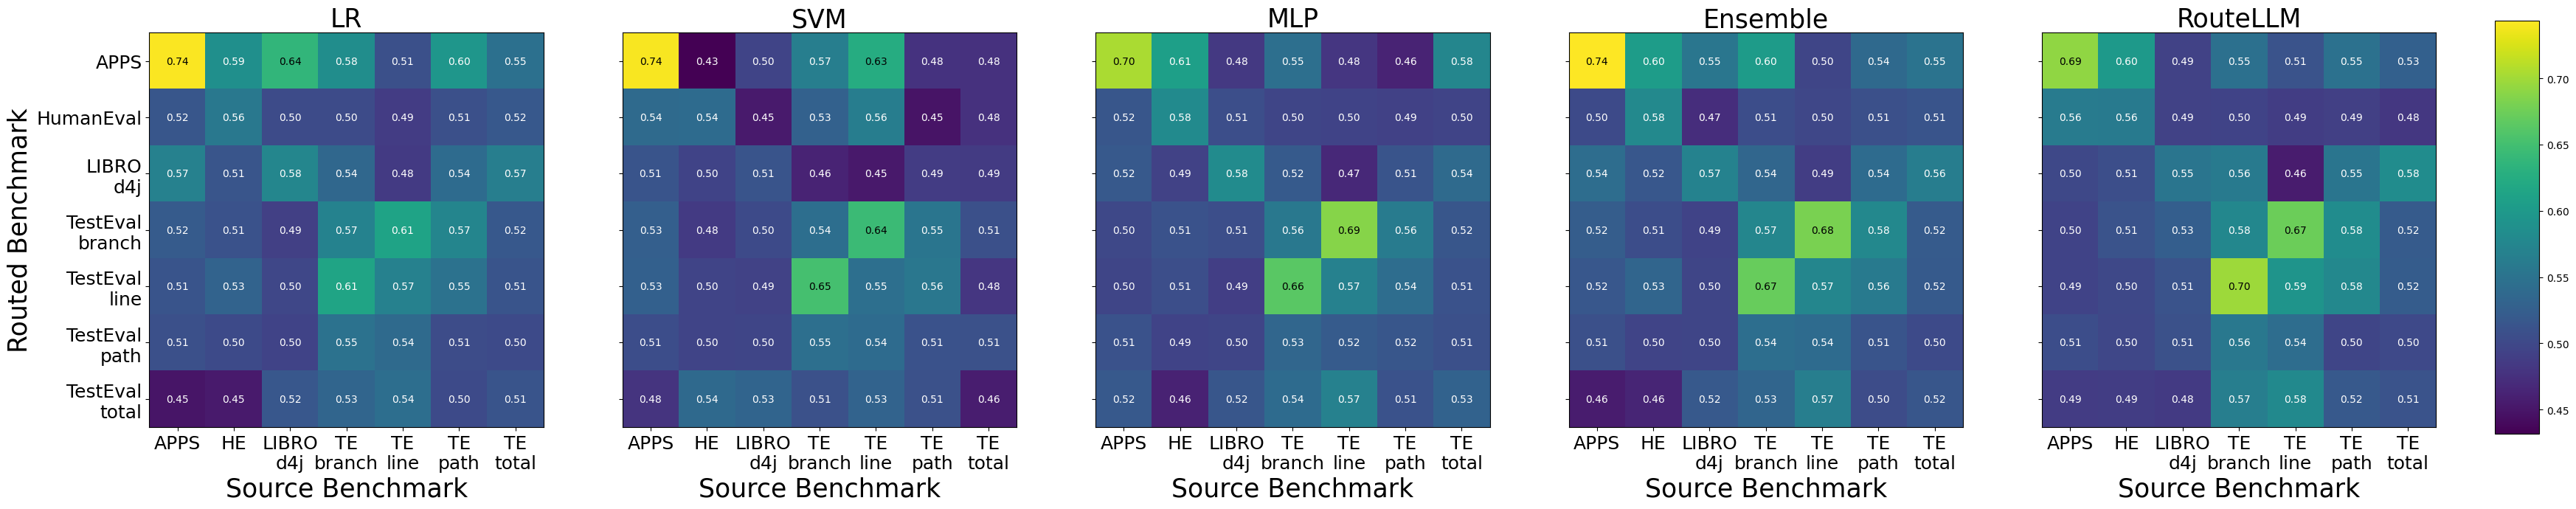

In [21]:
draw_heatmaps_for(stacked_df, 'internal state')

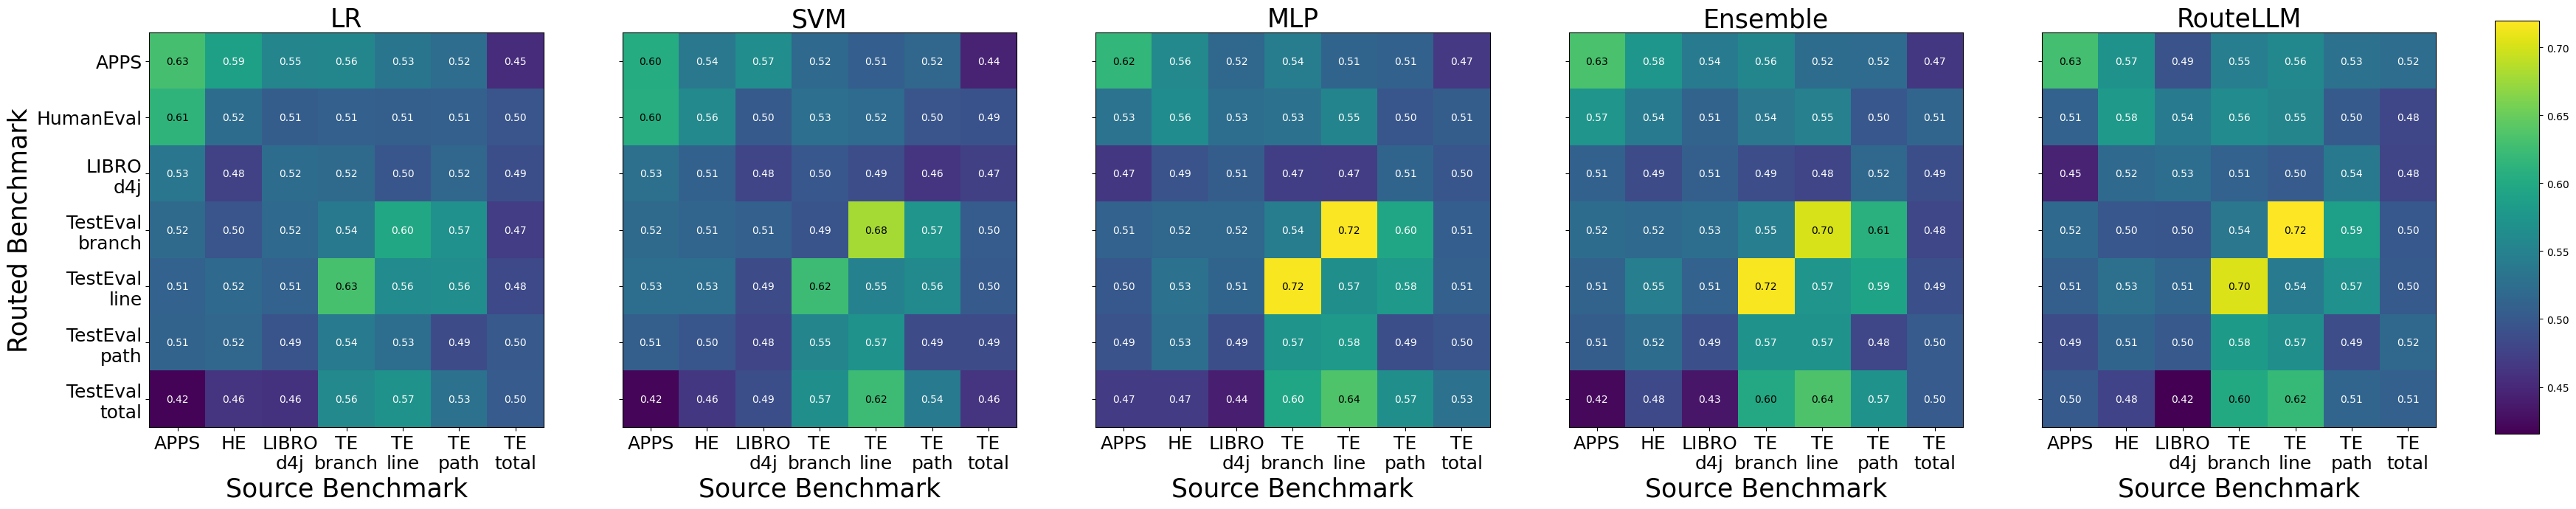

In [22]:
draw_heatmaps_for(stacked_df, 'prompt embedding')